In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

import xgboost
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

import lightgbm, sklearn
print("LightGBM:", lightgbm.__version__)
print("Scikit-learn:", sklearn.__version__)

import warnings
warnings.filterwarnings("ignore")

import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score

LightGBM: 4.6.0
Scikit-learn: 1.5.1


## Importing Libraries
This cell imports the essential Python libraries required for exploratory data analysis.
pandas is used for data manipulation and cleaning.
numpy supports numerical computations.
matplotlib and seaborn are used for data visualization.
These tools enable effective examination of patterns, distributions, and relationships within the dataset.

In [9]:

df = pd.read_csv(r"C:\Users\USER\Downloads\Retail-Marketing-Customer-Purchase-Prediction-main\Retail-Marketing-Customer-Purchase-Prediction-main\online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


## Loading the Dataset
The dataset is loaded into a pandas DataFrame. This allows structured access to rows and columns for analysis. Successfully loading the dataset confirms that it is ready for inspection and preprocessing.

In [11]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Viewing the Rows (df.head())

This helps confirm that the dataset was loaded correctly and gives insight into the type of variables present (numerical, categorical, boolean).

In [13]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## Checking Data Types (df.info())

This particular cell identifies the data type of each variable (integer, float, object, boolean).
This is important because:
Numerical variables can be analyzed statistically.
Categorical variables may require encoding before modeling.
Boolean variables represent binary categories.
It also shows whether any columns contain missing values.

In [16]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Statistical Summary (df.describe())

This provides summary statistics for numerical features, including:
Mean
Standard deviation
Minimum and maximum values
Quartiles
This helps to identify:
Skewed distributions

Extreme values (potential outliers)

General scale of variables.

In [18]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Checking Missing Values (df.isna().sum())

The dataset was examined for missing values using the isna().sum() function. The result showed zero missing values across all features. This indicates that the dataset is complete and does not require any imputation or removal of incomplete records. Therefore, the data is suitable for further exploratory analysis and model development.

In [20]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

## The unique() function
It is used to examine distinct values within categorical variables. This helped confirm the structure of key variables such as VisitorType, Month, and Revenue. The Revenue variable was confirmed to be binary, validating the classification nature of the problem.

In [22]:
df['Month'] = df['Month'].astype('category')
df['VisitorType'] = df ['VisitorType'].astype('category')
print("dataframe info after converting 'Month' and 'VisitorType' to category type:")
df.info()

dataframe info after converting 'Month' and 'VisitorType' to category type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  int64   
 12  Browser                  12330 non-null 


## **Exploratory Data Analysis**


- Target Variable Analysis

The target variable in this dataset is **Revenue**, which indicates whether a customer completed a purchase or not .

Count of buyers vs non-buyers:

In [26]:
df["Revenue"].value_counts()


Revenue
False    10422
True      1908
Name: count, dtype: int64

Purchase Percentage:

In [28]:
df["Revenue"].value_counts(normalize=True) * 100


Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

Remark

The distribution of the target variable (Revenue) shows that:
10,422 sessions (84.53%) did not result in a purchase (False).
1,908 sessions (15.47%) resulted in a completed transaction (True).
This indicates that the majority of website visits did not lead to a purchase. Only a small proportion of users converted into buyers.
The dataset therefore exhibits class imbalance, with non-buyers significantly outnumbering buyers. This imbalance is important because a predictive model could achieve high accuracy by simply predicting the majority class (no purchase) without truly learning purchasing behavior.
As a result, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered instead of relying solely on accuracy.

Purchase Distribution Chart

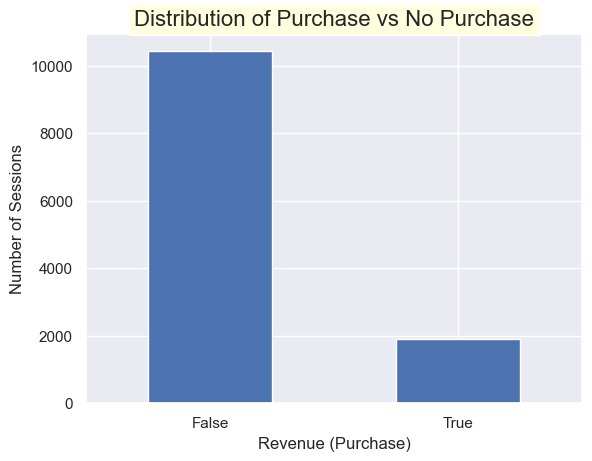

In [31]:
df["Revenue"].value_counts().plot(kind="bar")
plt.title("Distribution of Purchase vs No Purchase", fontsize ='16',bbox=dict(facecolor='lightyellow'))
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()


## **Summary Statistics of Numerical Features**

In [33]:
df.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


To better understand the dataset, we analyze the summary statistics of all numerical features. This includes measures such as:

Count – Number of non-null values

Mean – Average value

Standard Deviation (Std) – Measure of spread or variability

Minimum (Min) – Smallest value

25%, 50%, 75% (Quartiles) – Distribution of values

Maximum (Max) – Largest value

- Skewness Analysis

In [36]:
df.skew(numeric_only=True)


Administrative             1.960357
Administrative_Duration    5.615719
Informational              4.036464
Informational_Duration     7.579185
ProductRelated             4.341516
ProductRelated_Duration    7.263228
BounceRates                2.947855
ExitRates                  2.148789
PageValues                 6.382964
SpecialDay                 3.302667
OperatingSystems           2.066285
Browser                    3.242350
Region                     0.983549
TrafficType                1.962987
Weekend                    1.265962
Revenue                    1.909509
dtype: float64

- Product Interaction Analysis
This analysis examines how many product-related pages users visit during a session.

## **Distribution of ProductRelated Pages**

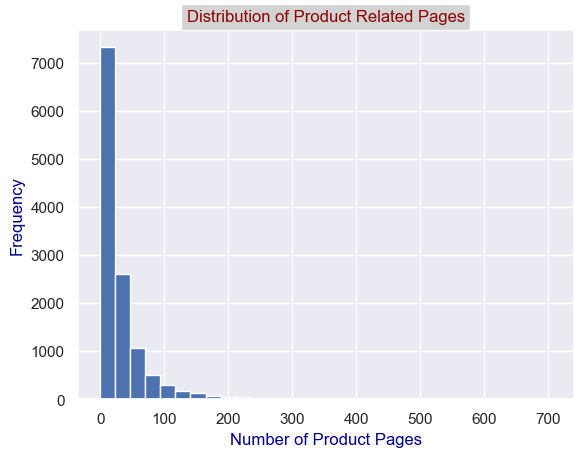

In [39]:
df["ProductRelated"].hist(bins=30)
plt.title("Distribution of Product Related Pages" , color='darkred', bbox=dict(facecolor='lightgrey'))
plt.xlabel("Number of Product Pages",color='darkblue')
plt.ylabel("Frequency", color='darkblue')
plt.show()


From the distribution, we can observe that most users visit only a small number of product pages, while a few users explore many pages. This means that only a few users explore products deeply.

- ProductRelated Pages vs Revenue

This analysis compares the number of product pages visited with whether revenue was generated.


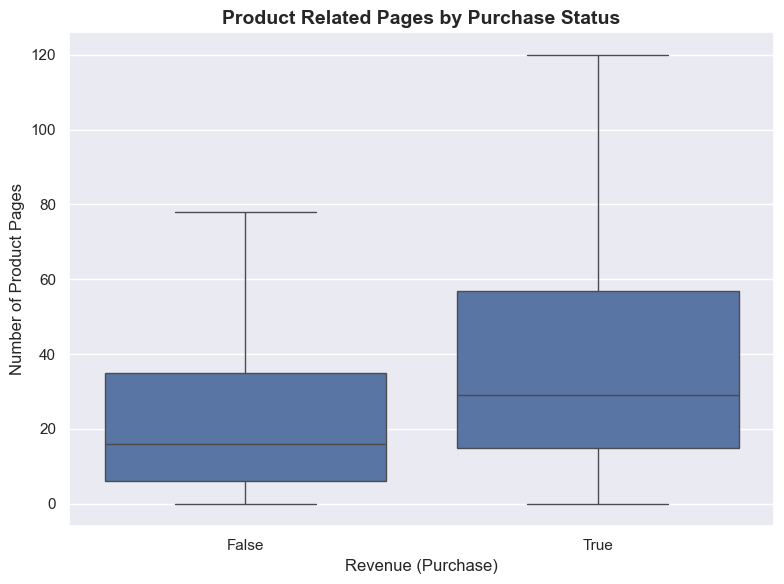

In [42]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="ProductRelated",
    data=df,
    showfliers=False
)

plt.title("Product Related Pages by Purchase Status",
          fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Number of Product Pages")
plt.tight_layout()
plt.show()


In [43]:
df.groupby("Revenue")["ProductRelated"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


• Purchasing sessions show a higher median number of product-related pages visited.

• Buyers explore more products before completing a transaction.

• The distribution is right-skewed, with a small number of very high-page sessions.

Business Interpretation:

Customers who browse more product pages are more likely to convert.
Exploration depth is positively associated with purchase probability.

## **ProductRelated Duration vs Revenue**

This shows how long users spend on product pages and whether they make a purchase.


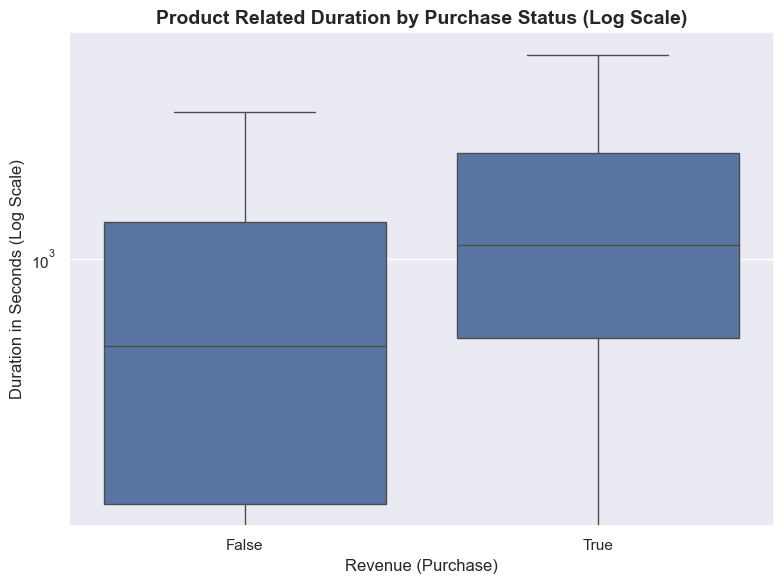

In [46]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="ProductRelated_Duration",
    data=df,
    showfliers=False
)

plt.yscale("log")  # Handle heavy skew

plt.title("Product Related Duration by Purchase Status (Log Scale)",
          fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Duration in Seconds (Log Scale)")
plt.tight_layout()
plt.show()




• Purchasing sessions show higher median ProductRelated_Duration.

• Buyers spend more time exploring product-related pages.

• The distribution is heavily right-skewed (few extremely long sessions).

Business Interpretation:

Time spent on product pages is a strong indicator of purchase intent.
Deeper product engagement increases conversion probability.

In [48]:
df.groupby("Revenue")["ProductRelated_Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


## **Engagement Metrics Analysis**

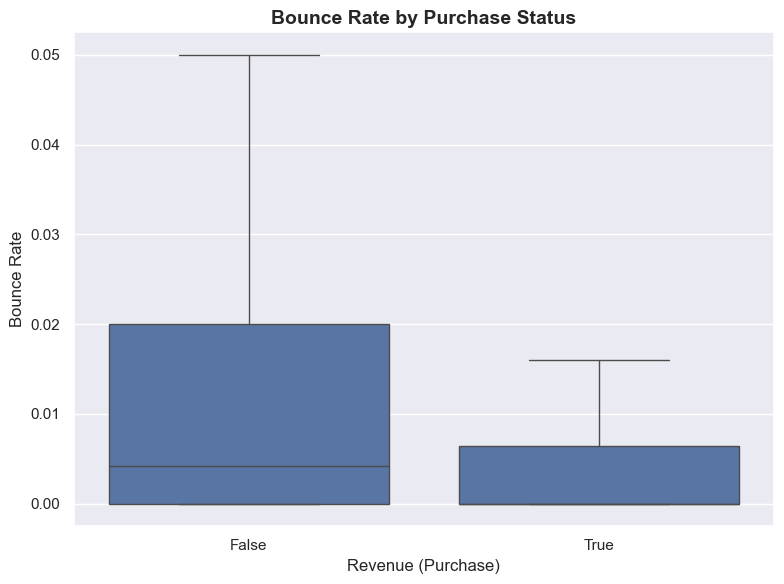

In [50]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="BounceRates",
    data=df,
    showfliers=False
)

plt.title("Bounce Rate by Purchase Status", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Bounce Rate")
plt.tight_layout()
plt.show()


Bounce rate represents the percentage of users who leave the website after viewing only one page. From the visualization, we can observe that sessions that generated revenue generally have lower bounce rates compared to non-purchasing sessions.

This suggests that users who stay and explore more pages are more likely to complete a purchase, while users with high bounce rates tend to leave quickly without buying.

- Exit Rate vs Revenue
This shows the relationship between exit rate and revenue.

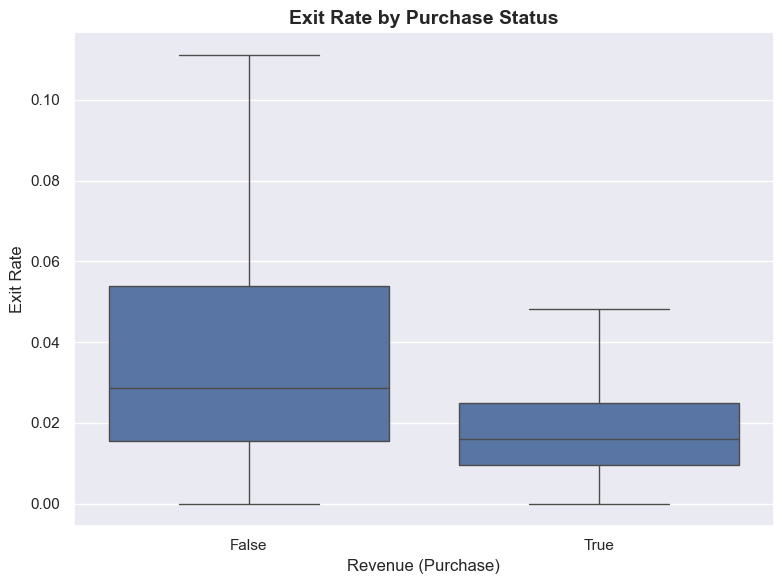

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="ExitRates",
    data=df,
    showfliers=False
)

plt.title("Exit Rate by Purchase Status", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Exit Rate")
plt.tight_layout()
plt.show()


In [54]:
df.groupby("Revenue")["ExitRates"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


Key Observations:

• Non-purchasing sessions (Revenue = False) have noticeably higher ExitRates.
• Purchasing sessions show lower median ExitRates.
• Distribution of ExitRates for non-buyers is more spread out and skewed upward.

Business Interpretation:

Higher exit rates reduce the likelihood of purchase.
Users who leave frequently during browsing are less engaged and less likely to convert.


- Page Value vs Revenue

Page value shows how important a page is in leading to a purchase

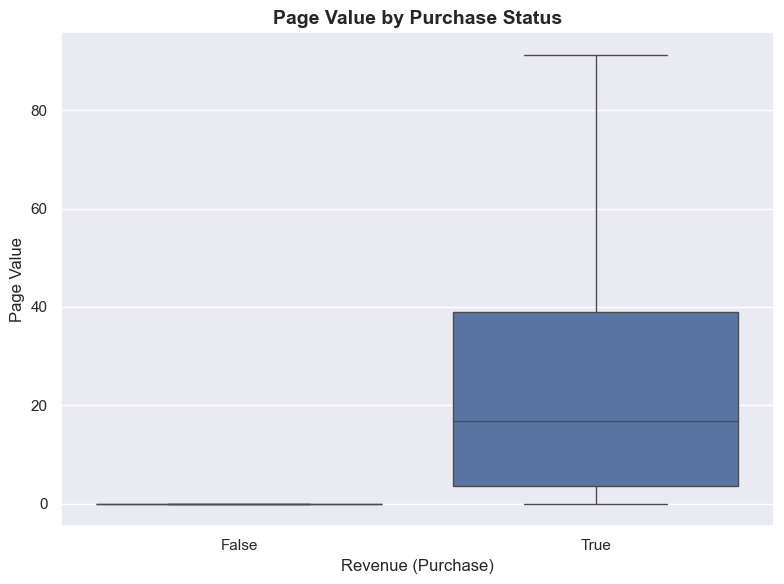

In [57]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="PageValues",
    data=df,
    showfliers=False   # Remove extreme outliers for clarity
)

plt.title("Page Value by Purchase Status", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Page Value")
plt.tight_layout()
plt.show()


In [58]:
df.groupby("Revenue")["PageValues"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


Key Observations:

• Customers who purchased (Revenue = True) show significantly higher PageValues.
• Median PageValue for buyers is substantially above non-buyers.
• Non-purchasers have PageValues concentrated near zero.
• The distribution is highly right-skewed (many small values, few large outliers).

Business Interpretation:

PageValues is a strong indicator of purchase intent.
Higher engagement with high-value pages strongly increases probability of conversion.





##**Visitor Type Analysis**

- Visitor Type Distribution
This shows the number of returning visitors and new visitors.

In [62]:
pd.crosstab(df["VisitorType"], df["Revenue"])


Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


Most users are returning visitors. This means many people come back to the website more than once.



- Conversion Rate by Visitor Type

In [65]:
pd.crosstab(df["VisitorType"], df["Revenue"], normalize="index") * 100


Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


Visitor Type Chart

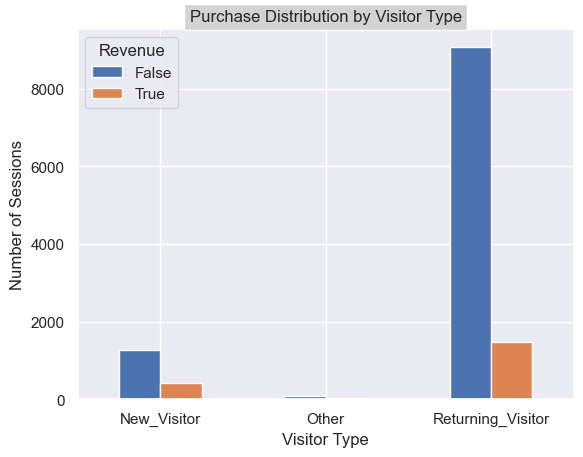

In [67]:
pd.crosstab(df["VisitorType"], df["Revenue"]).plot(kind="bar")
plt.title("Purchase Distribution by Visitor Type", bbox=dict(facecolor='lightgray'))
plt.xlabel("Visitor Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()


While most returning visitor sessions do not result in revenue (the large blue bar), a substantial number of sessions (orange bar) do generate revenue. This group is the main source of purchases.
A very small fraction of new visitor sessions result in revenue indicating a low initial conversion rate.
Conversion Rate Implication: The data suggests that visitors are much more likely to make a purchase on a subsequent visit rather than their first.

## **Weekend Effect Analysis**

- Weekend Conversion Rate

In [71]:
pd.crosstab(df["Weekend"], df["Revenue"], normalize="index") * 100


Revenue,False,True
Weekend,,
False,85.108856,14.891144
True,82.601116,17.398884


- Weekend Chart

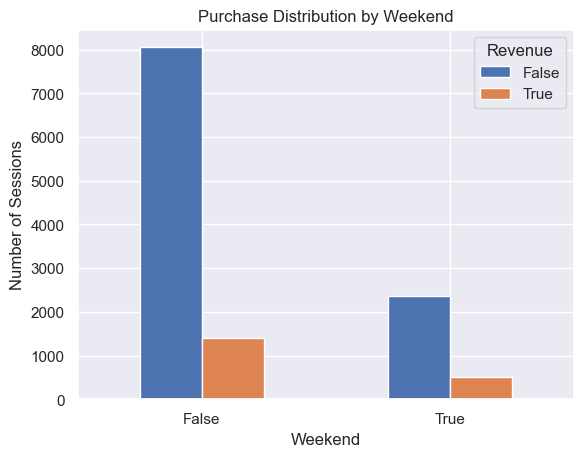

In [73]:
pd.crosstab(df["Weekend"], df["Revenue"]).plot(kind="bar")
plt.title("Purchase Distribution by Weekend")
plt.xlabel("Weekend")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()


From the visualization, it is evident that:
A higher number of sessions occur during weekdays compared to weekends.
In both cases (weekdays and weekends), the number of non-purchasing sessions is significantly higher than purchasing sessions.
Although weekday sessions are more frequent, weekend sessions also contribute to revenue generation.
This suggests that while traffic volume is higher during weekdays, weekend sessions may still play an important role in purchase behavior.




## Monthly (Seasonality) Analysis
The monthly analysis shows the percentage distribution of purchasing (Revenue = True) and non-purchasing sessions (Revenue = False) across different months.

In [76]:
#convert Month to Ordered Category
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)


In [77]:
df["Month"].value_counts().sort_index()


Month
Jan        0
Feb      184
Mar     1907
Apr        0
May     3364
June     288
Jul      432
Aug      433
Sep      448
Oct      549
Nov     2998
Dec     1727
Name: count, dtype: int64

## Monthly Purchase Chart

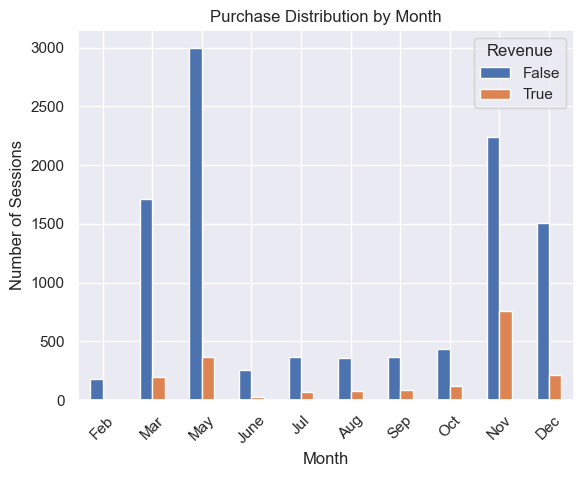

In [79]:
pd.crosstab(df["Month"], df["Revenue"]).plot(kind="bar")
plt.title("Purchase Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.show()


### Monthly Purchase Distribution

The number of sessions and purchases varies significantly across months, indicating strong seasonality in user behavior.

November shows a clear spike in both total sessions and purchases, with the highest number of conversions. This likely reflects major promotional events (e.g., Black Friday period), where purchase intent is significantly higher.

May also shows high traffic volume, but its conversion volume is proportionally lower compared to November, suggesting that not all high-traffic months translate into equally high conversion rates.

Early and mid-year months (June–September) show relatively lower purchase counts, indicating slower commercial periods.

Overall, purchasing behavior appears highly seasonal, with Q4 (especially November) being the strongest revenue-driving period.

### Conversion Rate by Month

In [82]:
pd.crosstab(df["Month"], df["Revenue"], normalize="index") * 100

Revenue,False,True
Month,,
Feb,98.369565,1.630435
Mar,89.931830,10.068170
May,89.149822,10.850178
June,89.930556,10.069444
Jul,84.722222,15.277778
Aug,82.448037,17.551963
Sep,80.803571,19.196429
Oct,79.052823,20.947177
Nov,74.649767,25.350233


In [83]:
monthly_conversion = pd.crosstab(df['Month'],df['Revenue'])


Plot Monthly Conversion Rate

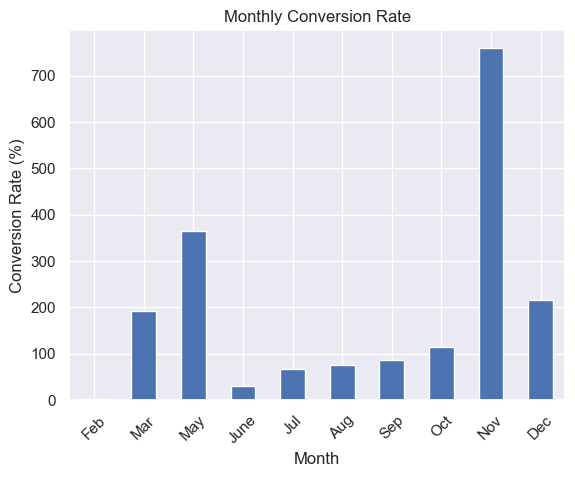

In [85]:
monthly_conversion[True].plot(kind="bar")

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

From the results, there is a clear seasonal trend in purchasing behavior. Conversion rates are significantly lower at the beginning of the year. However, purchase rates steadily increase from mid-year onward, peaking in November at 25.35%, which represents the highest conversion month.

This upward trend suggests strong seasonality in customer purchasing behavior, likely influenced by promotional events and holiday shopping periods.

## **Traffic Source Analysis**

Conversion Rate by Traffic Type

In [89]:
pd.crosstab(df["TrafficType"], df["Revenue"], normalize="index") * 100


Revenue,False,True
TrafficType,,
1,89.310486,10.689514
2,78.354204,21.645796
3,91.228070,8.771930
4,84.565014,15.434986
5,78.461538,21.538462
6,88.063063,11.936937
7,70.000000,30.000000
8,72.303207,27.696793
9,90.476190,9.523810




Conversion rates differ across traffic sources.

Some traffic types generate high volumes but low conversions, while others bring fewer but more qualified visitors.

This suggests that not all acquisition channels are equally effective, and marketing budgets should prioritize high-converting sources.

## **Region Performance Analysis**

In [92]:
pd.crosstab(df["Region"], df["Revenue"], normalize="index") * 100


Revenue,False,True
Region,,
1,83.870293,16.129707
2,83.450704,16.549296
3,85.476488,14.523512
4,85.194585,14.805415
5,83.647799,16.352201
6,86.086957,13.913043
7,84.362681,15.637319
8,87.096774,12.903226
9,83.170254,16.829746


### Performance based Region

Conversion rates vary slightly across regions.

While geographic differences are not extreme, certain regions demonstrate higher purchasing behavior.

This may reflect demographic, economic, or cultural factors influencing buying decisions.

## **Correlation Analysis**

Correlation Matrix

In [96]:
numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])
corr = numeric_df.corr()
corr


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,-0.006347,-0.025035,-0.005487,-0.033561,0.026417,0.138917
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,-0.007343,-0.015392,-0.005561,-0.014376,0.014990,0.093587
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,-0.009527,-0.038235,-0.029169,-0.034491,0.035785,0.095200
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,-0.009579,-0.019285,-0.027144,-0.024675,0.024078,0.070345
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,0.004290,-0.013146,-0.038122,-0.043064,0.016092,0.158538
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,0.002976,-0.007380,-0.033091,-0.036377,0.007311,0.152373
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,0.023823,-0.015772,-0.006485,0.078286,-0.046514,-0.150673
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,0.014567,-0.004442,-0.008907,0.078616,-0.062587,-0.207071
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,0.018508,0.045592,0.011315,0.012532,0.012002,0.492569
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,0.012652,0.003499,-0.016098,0.052301,-0.016767,-0.082305


Correlation Heatmap

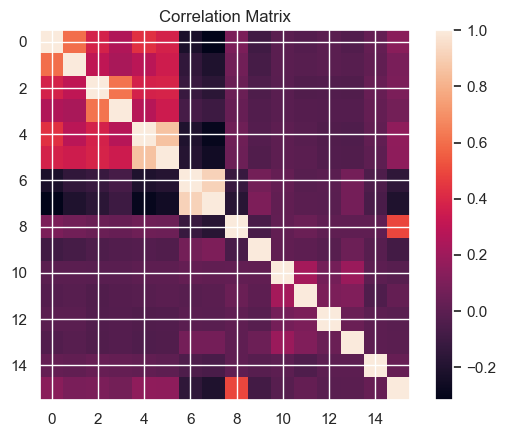

In [98]:
plt.imshow(corr)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()


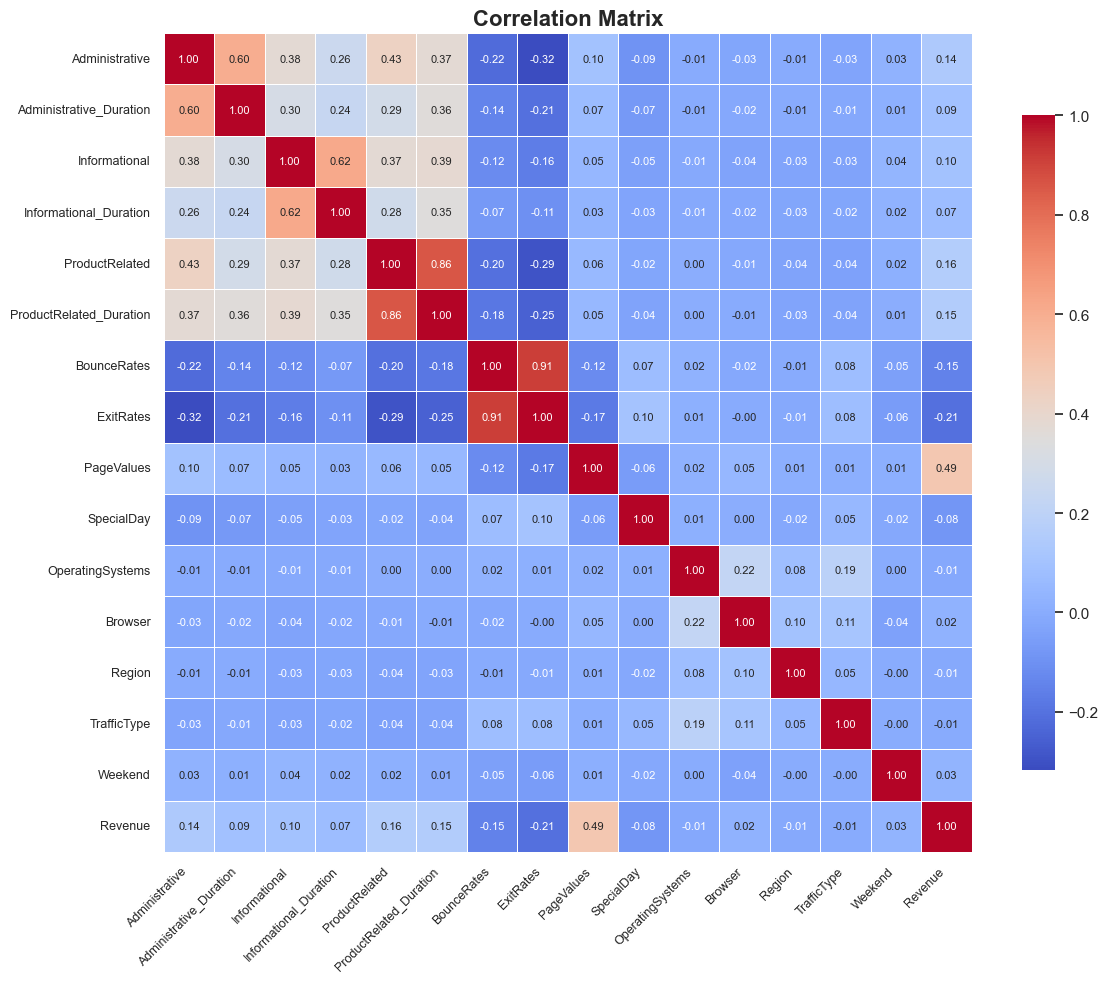

In [99]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title("Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Correlation

• PageValues shows the strongest positive correlation with Revenue.
• ExitRates and BounceRates are negatively correlated with Revenue.
• ProductRelated and ProductRelated_Duration are strongly correlated (multicolarity risk).
• Most categorical system variables (Browser, OS, Region) show weak correlation with Revenue.

Business Interpretation:
Customer engagement and page value are strong predictors of purchase behavior.
High exit and bounce rates reduce conversion probability.

Top Features Correlated with Revenue

In [102]:
corr["Revenue"].sort_values(ascending=False)


Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

## **Buyers vs Non-Buyers Comparison**

Mean Comparison

In [105]:
df.groupby("Revenue").mean(numeric_only=True)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend
Revenue,,,,,,,,,,,,,,,
False,2.117732,73.740111,0.451833,30.236237,28.714642,1069.987809,0.025317,0.047378,1.975998,0.068432,2.129726,2.339474,3.159278,4.078392,0.227308
True,3.393606,119.483244,0.786164,57.611427,48.210168,1876.209615,0.005117,0.019555,27.264518,0.023166,2.092767,2.453354,3.082285,4.021488,0.261530


### Buyers vs Non-Buyers

Buyers consistently show higher averages in:
- ProductRelated
- ProductRelated_Duration
- PageValues

They also show lower averages in:
- BounceRates
- ExitRates

This clearly differentiates engaged purchasing sessions from casual browsing sessions.

Median Comparison

In [108]:
df.groupby("Revenue").median(numeric_only=True)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend
Revenue,,,,,,,,,,,,,,,
False,0.0,0.000000,0.0,0.0,16.0,510.19000,0.004255,0.028571,0.000000,0.0,2.0,2.0,3.0,2.0,0.0
True,2.0,52.366667,0.0,0.0,29.0,1109.90625,0.000000,0.016000,16.758134,0.0,2.0,2.0,2.0,2.0,0.0


## **Total Session Duration Analysis**

In [110]:
df["Total_Duration"] = (
    df["Administrative_Duration"] +
    df["Informational_Duration"] +
    df["ProductRelated_Duration"]
)

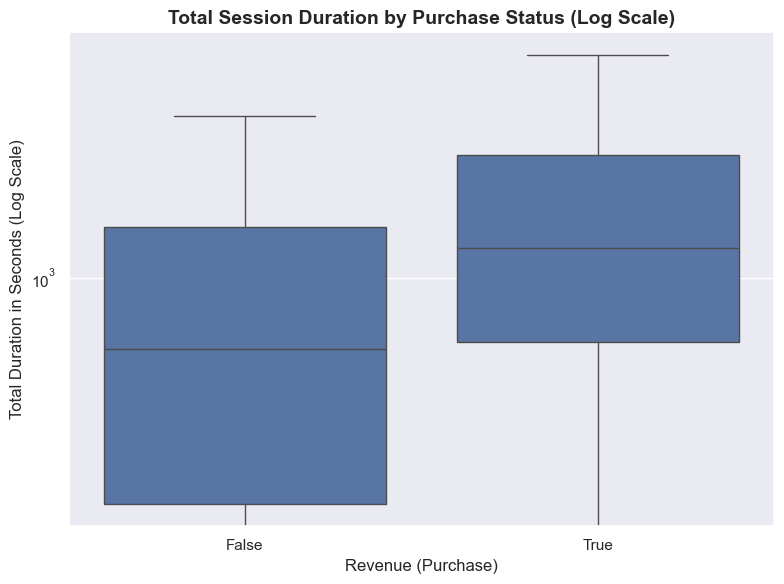

In [111]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Revenue",
    y="Total_Duration",
    data=df,
    showfliers=False
)

plt.yscale("log")

plt.title("Total Session Duration by Purchase Status (Log Scale)",
          fontsize=14, fontweight="bold")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Total Duration in Seconds (Log Scale)")
plt.tight_layout()
plt.show()


### Total Duration

Total browsing duration is higher among buyers compared to non-buyers.

Longer sessions are strongly associated with higher purchase probability, indicating that engagement depth is a key conversion driver.

## **Product Page Quartile Conversion**

In [114]:
df["ProductQuartile"] = pd.qcut(df["ProductRelated"], 4)

pd.crosstab(df["ProductQuartile"], df["Revenue"], normalize="index") * 100


Revenue,False,True
ProductQuartile,,
"(-0.001, 7.0]",94.898606,5.101394
"(7.0, 18.0]",86.056158,13.943842
"(18.0, 38.0]",80.251406,19.748594
"(38.0, 705.0]",76.367252,23.632748


### Product Page Quartile

Conversion rate increases steadily across higher quartiles of product page views.

Users who view the most product pages are significantly more likely to purchase.

This demonstrates a strong behavioral gradient between low-engagement and high-engagement users.

In [116]:
monthly_conversion = pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

monthly_conversion


Revenue,False,True
Month,,
Feb,98.369565,1.630435
Mar,89.931830,10.068170
May,89.149822,10.850178
June,89.930556,10.069444
Jul,84.722222,15.277778
Aug,82.448037,17.551963
Sep,80.803571,19.196429
Oct,79.052823,20.947177
Nov,74.649767,25.350233


• Conversion rate increases steadily from mid-year onward.

• February shows extremely low conversion (-1.6%).

• Conversion peaks in November (-25.3%).
• There is a strong upward seasonal trend from July to November.

Business Interpretation:

The sharp rise in Q4 suggests strong seasonal purchasing behavior.
November likely reflects holiday shopping effects (e.g., promotions, Black Friday).

# Modelling

In [119]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,ProductQuartile
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0.000000,"(-0.001, 7.0]"
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,64.000000,"(-0.001, 7.0]"
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0.000000,"(-0.001, 7.0]"
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,2.666667,"(-0.001, 7.0]"
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,627.500000,"(7.0, 18.0]"


## Preprocessing

Numeric: median imputation + standard scaling. Categorical: mode imputation + label encoding.

This preprocessing pipeline systematically transforms raw data into machine-learning-ready format by creating separate processing streams for numerical and categorical variables for handling missing values, scaling numerical features, and encoding categories. It then seamlessly combines them into a unified feature set that preserves data integrity while making it compatible with ML algorithms.

In [121]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'Total_Duration']

In [122]:
categorical_cols = df.select_dtypes(include=["category"]).columns.tolist()

categorical_cols

['Month', 'VisitorType', 'ProductQuartile']

In [123]:
df.duplicated().sum()

125

In [124]:
df.drop_duplicates(inplace=True)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12205 non-null  int64   
 1   Administrative_Duration  12205 non-null  float64 
 2   Informational            12205 non-null  int64   
 3   Informational_Duration   12205 non-null  float64 
 4   ProductRelated           12205 non-null  int64   
 5   ProductRelated_Duration  12205 non-null  float64 
 6   BounceRates              12205 non-null  float64 
 7   ExitRates                12205 non-null  float64 
 8   PageValues               12205 non-null  float64 
 9   SpecialDay               12205 non-null  float64 
 10  Month                    12205 non-null  category
 11  OperatingSystems         12205 non-null  int64   
 12  Browser                  12205 non-null  int64   
 13  Region                   12205 non-null  int64   
 14  TrafficType

In [126]:
df.drop(columns=['Total_Duration', 'ProductQuartile'], inplace=True)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12205 non-null  int64   
 1   Administrative_Duration  12205 non-null  float64 
 2   Informational            12205 non-null  int64   
 3   Informational_Duration   12205 non-null  float64 
 4   ProductRelated           12205 non-null  int64   
 5   ProductRelated_Duration  12205 non-null  float64 
 6   BounceRates              12205 non-null  float64 
 7   ExitRates                12205 non-null  float64 
 8   PageValues               12205 non-null  float64 
 9   SpecialDay               12205 non-null  float64 
 10  Month                    12205 non-null  category
 11  OperatingSystems         12205 non-null  int64   
 12  Browser                  12205 non-null  int64   
 13  Region                   12205 non-null  int64   
 14  TrafficType

In [128]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [129]:
num_cols = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()

num_cols

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

In [130]:
df["Revenue"] = df["Revenue"].astype("int")

In [131]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


In [132]:
cat_cols = df.select_dtypes(include = ["category", "bool"]).columns.tolist()

cat_cols

['Month', 'VisitorType', 'Weekend']

## Feature Encoding

### Preparing Features and Target

X - Features

y - Target variable

In [135]:
X = df.drop(columns="Revenue")

y = df["Revenue"]

In [136]:
for cols in cat_cols:
    le = LabelEncoder()
    X[cols] = le.fit_transform(X[cols])

In [137]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1


## Feature Correlation

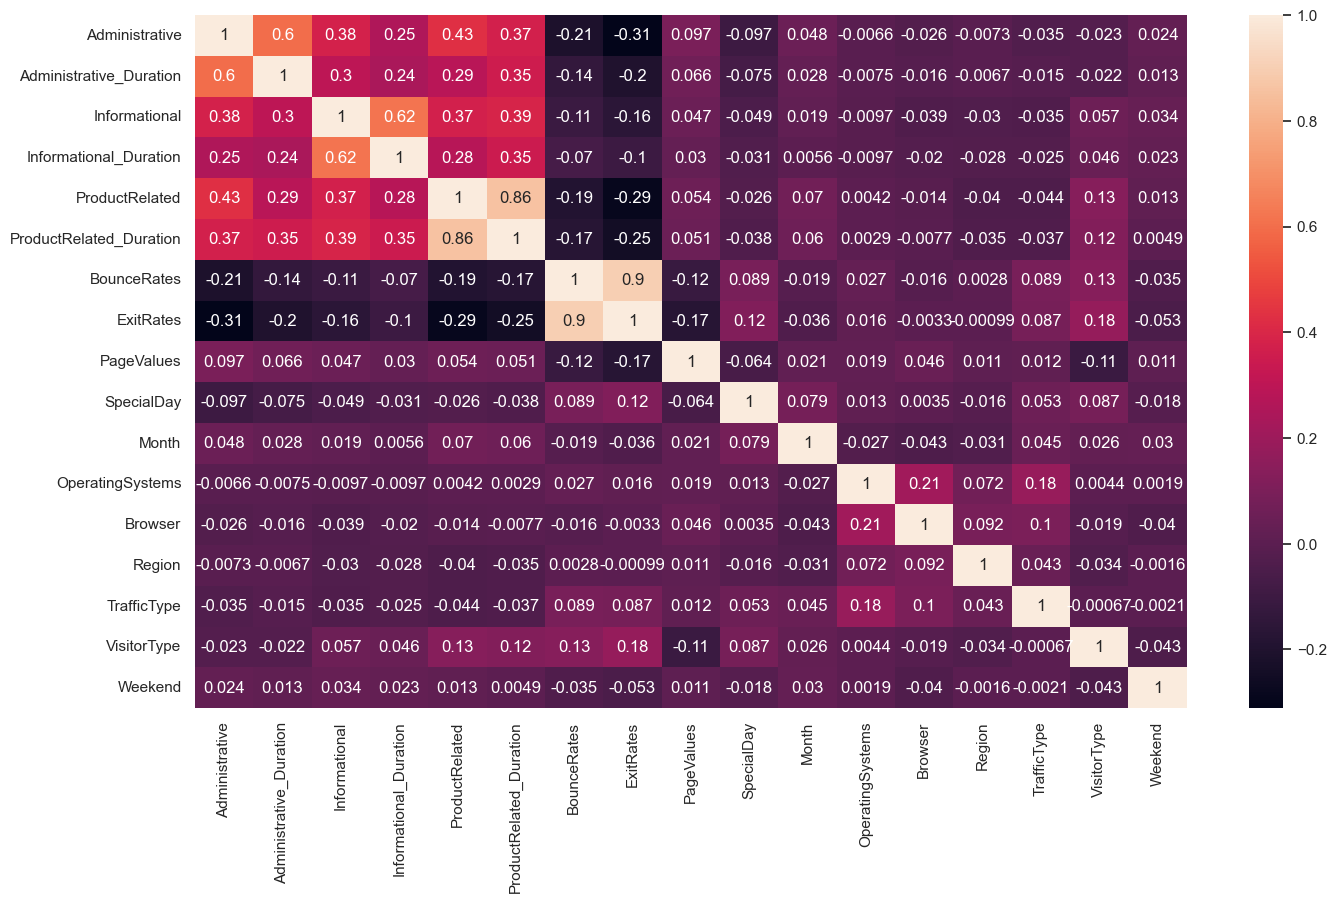

In [139]:
plt.figure(figsize=(16, 9))

sns.heatmap(X.corr(), annot=True)

plt.show()

# Feature Scaling

In [141]:
scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [142]:
scaledX

array([[-0.70230237, -0.46001931, -0.3988242 , ..., -0.76532112,
         0.40967016, -0.55308794],
       [-0.70230237, -0.46001931, -0.3988242 , ..., -0.51634748,
         0.40967016, -0.55308794],
       [-0.70230237, -0.46001931, -0.3988242 , ..., -0.26737383,
         0.40967016, -0.55308794],
       ...,
       [-0.70230237, -0.46001931, -0.3988242 , ...,  2.22236264,
         0.40967016,  1.80803074],
       [ 0.49879066, -0.03744737, -0.3988242 , ...,  1.72441534,
         0.40967016, -0.55308794],
       [-0.70230237, -0.46001931, -0.3988242 , ..., -0.51634748,
        -2.4746819 ,  1.80803074]])

In [143]:
y.value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

# Train-Test Split

For retail machine learning, an 80-20 stratified train-test split with a fixed random state maximizes training data while ensuring valid evaluation. Stratification preserves the real-world 15:85 purchase ratio across both sets, preventing misleading metrics that could misdirect marketing spend. The fixed random state guarantees reproducibility essential for reliable campaign benchmarking and revenue forecasting.

In [145]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size=0.2, random_state=42)

## Training

- Baseline Models

We'll train Logistic Regression, Random Forest, XGBoost, SVM (RBF) and LightGBM.

We are utilizing these our because:

Logistic Regression → simple, interpretable baseline for binary classification.

Random Forest → strong nonlinear model, robust and balanced.

XGBoost (Optuna) → powerful tuned model, often top performer for tabular data.

SVM (RBF) → Strong on high-dimensional, mixed-scale data.

LightGBM → Leaf-wise tree growth; better accuracy on imbalanced data

## Logistic Regression

In [148]:
log = LogisticRegression()

log.fit(X_train, y_train)

LogisticRegression()

In [149]:
log_preds = log.predict(X_test)

accuracy_score(y_test, log_preds)

0.8877509217533798

In [150]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2079
           1       0.75      0.36      0.49       362

    accuracy                           0.89      2441
   macro avg       0.82      0.67      0.71      2441
weighted avg       0.88      0.89      0.87      2441



## Random Forest

In [152]:
forest = RandomForestClassifier(random_state=42)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [153]:
forest_preds = forest.predict(X_test)

accuracy_score(y_test, forest_preds)

0.9041376485047112

In [154]:
print(classification_report(y_test, forest_preds))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.74      0.54      0.63       362

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



## XGBoost

In [156]:
boost = XGBClassifier(random_state=42)

boost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [157]:
boost_preds = boost.predict(X_test)

accuracy_score(y_test, boost_preds)

0.8992216304793118

In [158]:
print(classification_report(y_test, boost_preds))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2079
           1       0.70      0.56      0.62       362

    accuracy                           0.90      2441
   macro avg       0.81      0.76      0.78      2441
weighted avg       0.89      0.90      0.89      2441



## SVM with RBF Kernel

In [160]:
svm_rbf = SVC(kernel='rbf', random_state=42)

svm_rbf.fit(X_train, y_train)

SVC(random_state=42)

In [161]:
svm_rbf_preds = svm_rbf.predict(X_test)

accuracy_score(y_test, svm_rbf_preds)

0.8955346169602622

In [162]:
print(classification_report(y_test, svm_rbf_preds))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2079
           1       0.75      0.44      0.56       362

    accuracy                           0.90      2441
   macro avg       0.83      0.71      0.75      2441
weighted avg       0.89      0.90      0.88      2441



## LightGBM

In [164]:
light = LGBMClassifier(random_state=42)

light.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1546, number of negative: 8218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1899
[LightGBM] [Info] Number of data points in the train set: 9764, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158337 -> initscore=-1.670656
[LightGBM] [Info] Start training from score -1.670656


LGBMClassifier(random_state=42)

In [165]:
light_preds = light.predict(X_test)

accuracy_score(y_test, light_preds)

0.9020893076607948

In [166]:
print(classification_report(y_test, light_preds))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2079
           1       0.71      0.58      0.64       362

    accuracy                           0.90      2441
   macro avg       0.82      0.77      0.79      2441
weighted avg       0.90      0.90      0.90      2441



In [167]:
cm = confusion_matrix(y_test, log_preds)

cm

array([[2035,   44],
       [ 230,  132]], dtype=int64)

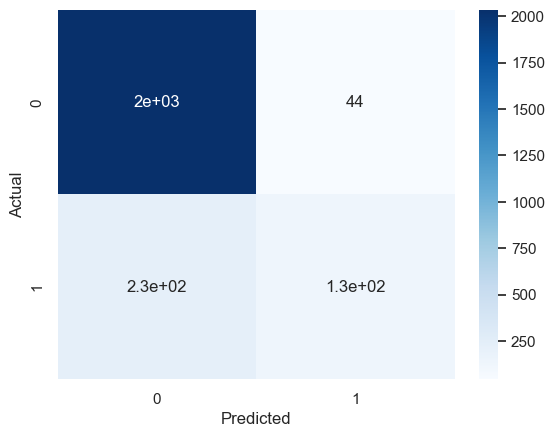

In [168]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [169]:
cm_forest = confusion_matrix(y_test, forest_preds)

cm_forest

array([[2010,   69],
       [ 165,  197]], dtype=int64)

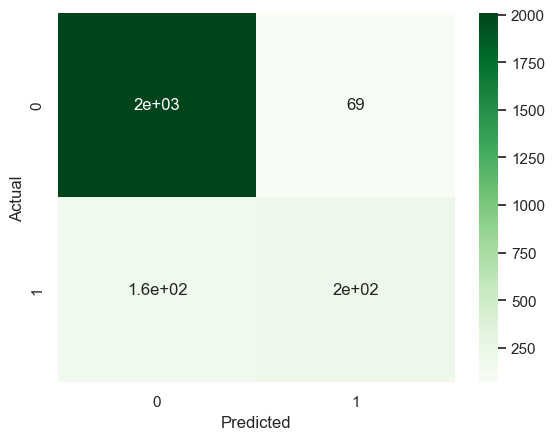

In [170]:
sns.heatmap(cm_forest, annot=True, cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [171]:
cm_light = confusion_matrix(y_test, light_preds)

cm_light

array([[1993,   86],
       [ 153,  209]], dtype=int64)

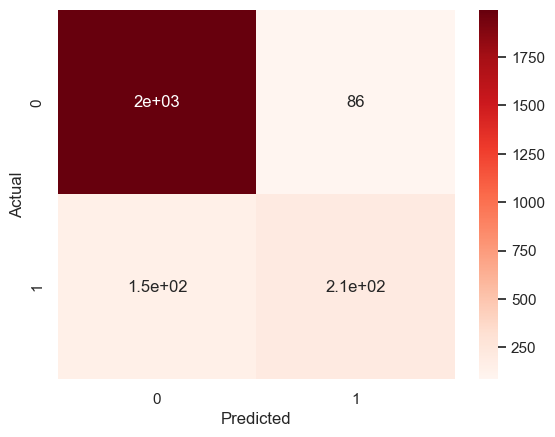

In [172]:
sns.heatmap(cm_light, annot=True, cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [173]:
cm_boost = confusion_matrix(y_test, boost_preds)

cm_boost

array([[1991,   88],
       [ 158,  204]], dtype=int64)

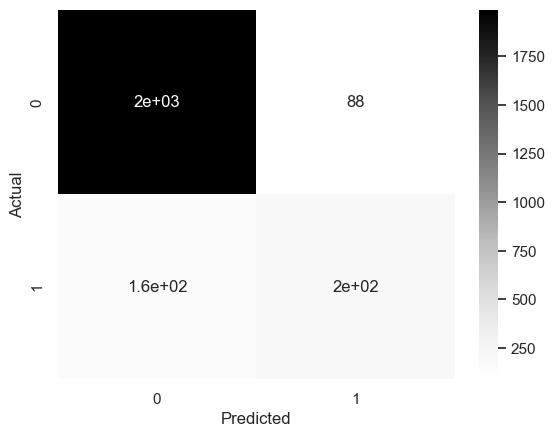

In [174]:
sns.heatmap(cm_boost, annot=True, cmap="Greys")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# F1 Score

## ROC Curve Random Forest

In [177]:
forest_prob = forest.predict_proba(X_test)[:, 1]

forest_prob

array([0.04, 0.65, 0.  , ..., 0.  , 0.01, 0.32])

In [178]:
auc_score = roc_auc_score(y_test, forest_prob)

auc_score

0.9232425544580241

In [179]:
fpr, tpr, threshold = roc_curve(y_test, forest_prob)

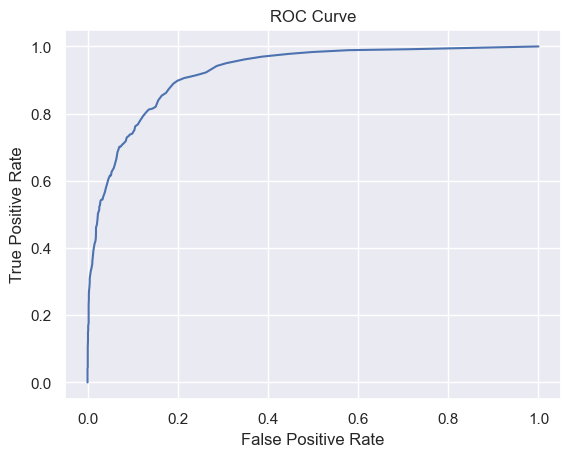

In [180]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [181]:
forest_preds

array([0, 1, 0, ..., 0, 0, 0])

In [182]:
y_test

6045     0
7750     1
203      0
10452    0
1177     0
        ..
8420     0
2679     0
11378    0
7733     0
8431     0
Name: Revenue, Length: 2441, dtype: int32

## ROC curve for LightGBM

In [184]:
light_prob = light.predict_proba(X_test)[:, 1]

light_prob

array([0.03230723, 0.79408537, 0.00105361, ..., 0.00087394, 0.00568616,
       0.2048328 ])

In [185]:
auc_score_light = roc_auc_score(y_test, light_prob)

auc_score_light

0.9292636972194983

In [186]:
light_fpr, light_tpr, _ = roc_curve(y_test, light_prob)

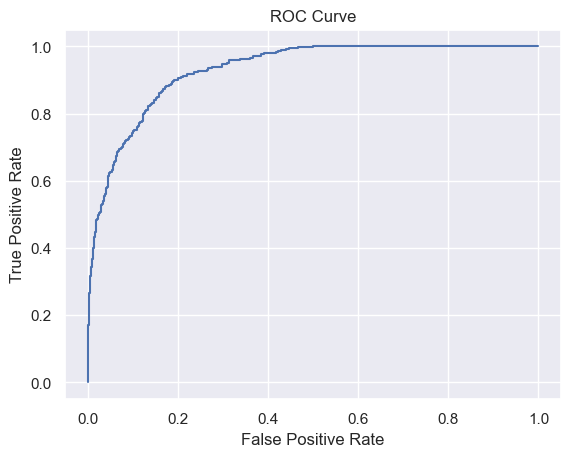

In [187]:
plt.plot(light_fpr, light_tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## ROC Curve for XGBoost

In [189]:
xgb_prob = boost.predict_proba(X_test)[:, 1]

xgb_prob

array([8.2190685e-02, 8.6476749e-01, 2.0985107e-04, ..., 1.3055849e-04,
       2.9601213e-03, 4.9717793e-01], dtype=float32)

In [190]:
xgb_auc = roc_auc_score(y_test, xgb_prob)

xgb_auc

0.9234398709536831

In [191]:
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

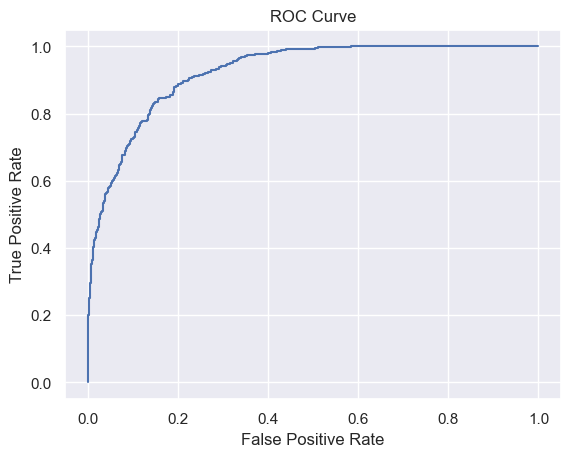

In [192]:
plt.plot(xgb_fpr, xgb_tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Optuna hyperparameter tuning for Random Forest

We will run a Optuna search to optimize the hyperparameter.

In [194]:
# Define the objective function for Optuna
def objective(trial):
    """Objective function for Optuna hyperparameter tuning."""
    # Define hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 50, step=5)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20, step=2)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10, step=1)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])  # Controls feature selection

    # Initialize the model with suggested hyperparameters
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Perform cross-validation (5-fold Stratified for classification)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

    # Return the mean F1 score (maximize this)
    return np.mean(scores)

# Create and optimize the study
study = optuna.create_study(direction="maximize")  # We want to maximize F1 score
study.optimize(objective, n_trials=50, n_jobs=-1)  # Run 200 trials in parallel

[I 2026-03-07 14:51:31,834] A new study created in memory with name: no-name-2e19a82e-d816-48dd-95b1-6caa1e53775c
[I 2026-03-07 14:52:40,283] Trial 2 finished with value: 0.8962543578566062 and parameters: {'n_estimators': 400, 'max_depth': 45, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 2 with value: 0.8962543578566062.
[I 2026-03-07 14:52:52,640] Trial 5 finished with value: 0.8970982019498003 and parameters: {'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 5 with value: 0.8970982019498003.
[I 2026-03-07 14:53:03,956] Trial 3 finished with value: 0.8970678016227559 and parameters: {'n_estimators': 150, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 5 with value: 0.8970982019498003.
[I 2026-03-07 14:53:06,918] Trial 4 finished with value: 0.897745120744357 and parameters: {'n_estimators': 350, 'max_depth': 5, 'mi

In [195]:
# Print the best hyperparameters
print("Best Hyperparameters:", study.best_params)
print(f"Best F1 Score:        {study.best_value:.4f}")

Best Hyperparameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None}
Best F1 Score:        0.8988


In [196]:
# Train final model with best hyperparameters
best_params = study.best_params

best_rf = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

# Fit and evaluate
best_rf.fit(X_train, y_train)
best_rf_preds = best_rf.predict(X_test)

print("===== Tuned Random Forest Classifier =====")
print("Accuracy:", accuracy_score(y_test, best_rf_preds))
print(classification_report(y_test, best_rf_preds))

===== Tuned Random Forest Classifier =====
Accuracy: 0.9045473166734944
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2079
           1       0.73      0.56      0.64       362

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



In [197]:
# Convert y_test and y_pred to NumPy arrays
y_test_array = np.array(y_test)
y_pred_array = np.array(best_rf_preds)

# Create sample indices
sample_indices = np.arange(len(y_test_array))

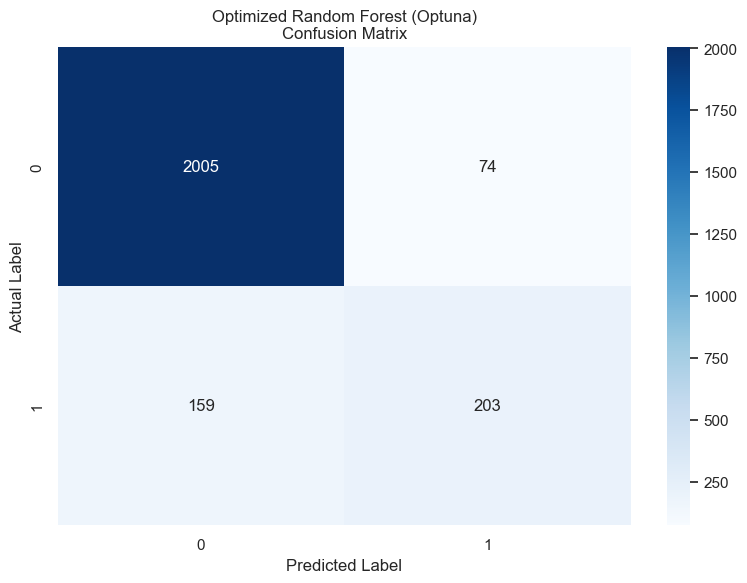

In [198]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_array, y_pred_array)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_array),
            yticklabels=np.unique(y_test_array))
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Optimized Random Forest (Optuna)\nConfusion Matrix")
plt.tight_layout()
plt.show()

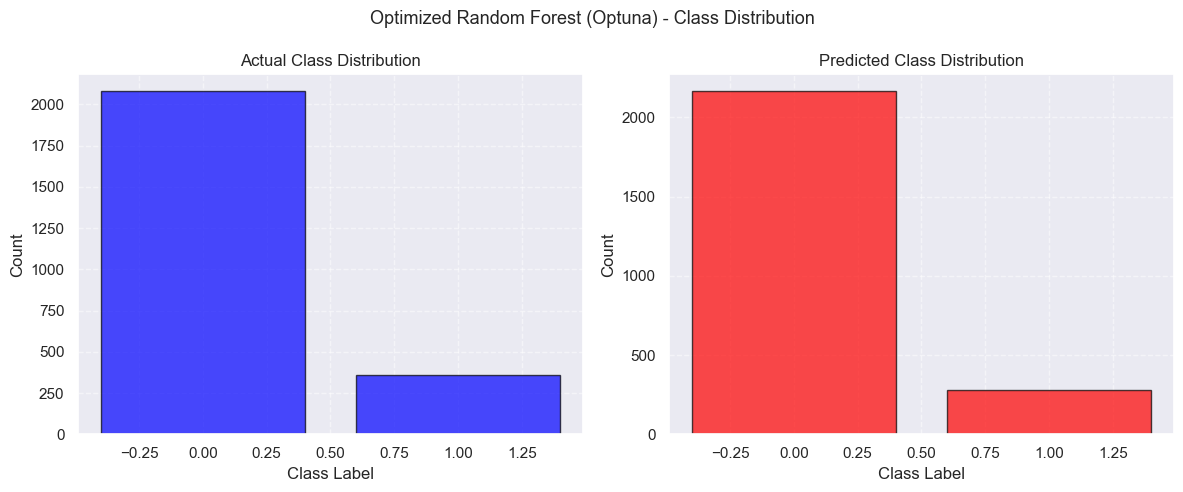

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(*np.unique(y_test_array, return_counts=True), color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title("Actual Class Distribution")
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].bar(*np.unique(y_pred_array, return_counts=True), color='red', alpha=0.7, edgecolor='black')
axes[1].set_title("Predicted Class Distribution")
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Optimized Random Forest (Optuna) - Class Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# Feature Importance for Random Forest 

===== Feature Importance Scores =====
                Feature  Importance
             PageValues    0.774054
            BounceRates    0.069962
                  Month    0.041456
         Administrative    0.025665
ProductRelated_Duration    0.025450
         ProductRelated    0.021646
              ExitRates    0.015037
Administrative_Duration    0.012130
            TrafficType    0.002917
                 Region    0.002562
 Informational_Duration    0.002507
            VisitorType    0.001992
                Browser    0.001816
          Informational    0.001449
                Weekend    0.000664
       OperatingSystems    0.000647
             SpecialDay    0.000045


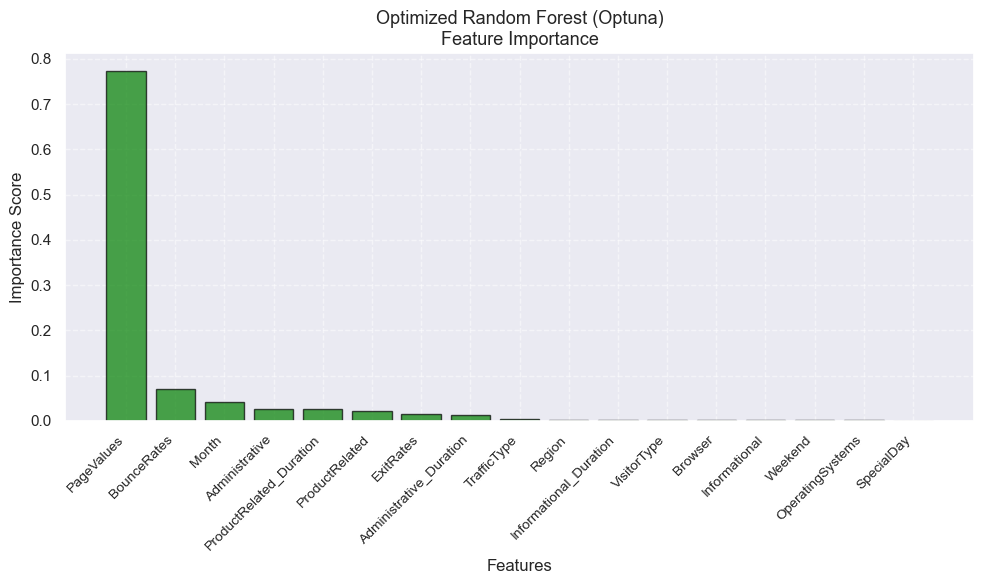

In [201]:
# Feature Importance 

feature_names = list(X.columns)  # Extract before train_test_split converts to array

feature_importance = best_rf.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

# Create a DataFrame for better visibility
feature_importance_df = pd.DataFrame({
    'Feature'   : np.array(feature_names)[sorted_idx],
    'Importance': feature_importance[sorted_idx]
})

print("===== Feature Importance Scores =====")
print(feature_importance_df.to_string(index=False))

# ── Plot Feature Importance 
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)),
        feature_importance[sorted_idx],
        color='green', alpha=0.7, edgecolor='black')

plt.xticks(range(len(feature_importance)),
           np.array(feature_names)[sorted_idx],
           rotation=45, ha='right', fontsize=10)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.title("Optimized Random Forest (Optuna)\nFeature Importance", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optuna hyperparameter tuning for LightGBM

In [203]:
# Define the objective function for Optuna
def objective(trial):
    """Objective function for Optuna hyperparameter tuning."""
    # Define hyperparameter search space
    n_estimators      = trial.suggest_int("n_estimators", 50, 500, step=50)
    max_depth         = trial.suggest_int("max_depth", 3, 15, step=1)
    learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    num_leaves        = trial.suggest_int("num_leaves", 20, 150, step=10)
    min_child_samples = trial.suggest_int("min_child_samples", 10, 100, step=10)
    subsample         = trial.suggest_float("subsample", 0.5, 1.0, step=0.1)
    colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0, step=0.1)  # Controls feature selection
    reg_alpha         = trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True)        # L1 regularization
    reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True)       # L2 regularization

    # Initialize the model with suggested hyperparameters
    lgbm = LGBMClassifier(
        n_estimators      = n_estimators,
        max_depth         = max_depth,
        learning_rate     = learning_rate,
        num_leaves        = num_leaves,
        min_child_samples = min_child_samples,
        subsample         = subsample,
        colsample_bytree  = colsample_bytree,
        reg_alpha         = reg_alpha,
        reg_lambda        = reg_lambda,
        random_state      = 42,
        n_jobs            = -1
    )

    # Perform cross-validation (5-fold Stratified for classification)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(lgbm, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

    # Return the mean F1 score (maximize this)
    return np.mean(scores)

# Create and optimize the study
study = optuna.create_study(direction="maximize")  # We want to maximize F1 score
study.optimize(objective, n_trials=50, n_jobs=-1)  # Run 50 trials in parallel

[I 2026-03-07 14:59:05,609] A new study created in memory with name: no-name-8d0bbb51-48c9-4c7a-9489-70d659880927
[I 2026-03-07 14:59:22,608] Trial 3 finished with value: 0.8983619866344092 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.018862393436113085, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 0.6, 'reg_alpha': 1.513170221114685e-05, 'reg_lambda': 0.020629818812630995}. Best is trial 3 with value: 0.8983619866344092.
[I 2026-03-07 14:59:24,755] Trial 5 finished with value: 0.8278730266415243 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.012819807382105619, 'num_leaves': 30, 'min_child_samples': 60, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 4.367186969356143e-08, 'reg_lambda': 3.2841913099093944e-07}. Best is trial 3 with value: 0.8983619866344092.
[I 2026-03-07 14:59:31,363] Trial 2 finished with value: 0.897080980733706 and parameters: {'n_estimators': 100, 'max_depth': 5, 'le

In [204]:
# Print the best hyperparameters
print("Best Hyperparameters:", study.best_params)
print(f"Best F1 Score:        {study.best_value:.4f}")

Best Hyperparameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.016241941467076696, 'num_leaves': 100, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 0.6, 'reg_alpha': 4.372349608794126e-06, 'reg_lambda': 0.22758369418943986}
Best F1 Score:        0.9008


In [205]:
# Train final model with best hyperparameters
best_params = study.best_params

best_lgbm = LGBMClassifier(
    n_estimators      = best_params["n_estimators"],
    max_depth         = best_params["max_depth"],
    learning_rate     = best_params["learning_rate"],
    num_leaves        = best_params["num_leaves"],
    min_child_samples = best_params["min_child_samples"],
    subsample         = best_params["subsample"],
    colsample_bytree  = best_params["colsample_bytree"],
    reg_alpha         = best_params["reg_alpha"],
    reg_lambda        = best_params["reg_lambda"],
    random_state      = 42,
    n_jobs            = -1
)

# Fit and evaluate
best_lgbm.fit(X_train, y_train)
best_lgbm_preds = best_lgbm.predict(X_test)

print("===== Tuned LightGBM Classifier (Optuna) =====")
print("Accuracy:", accuracy_score(y_test, best_lgbm_preds))
print(classification_report(y_test, best_lgbm_preds))

[LightGBM] [Info] Number of positive: 1546, number of negative: 8218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1899
[LightGBM] [Info] Number of data points in the train set: 9764, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158337 -> initscore=-1.670656
[LightGBM] [Info] Start training from score -1.670656
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [206]:
# Convert y_test and y_pred to NumPy arrays
y_test_array = np.array(y_test)
y_pred_array = np.array(best_lgbm_preds)

# Create sample indices
sample_indices = np.arange(len(y_test_array))

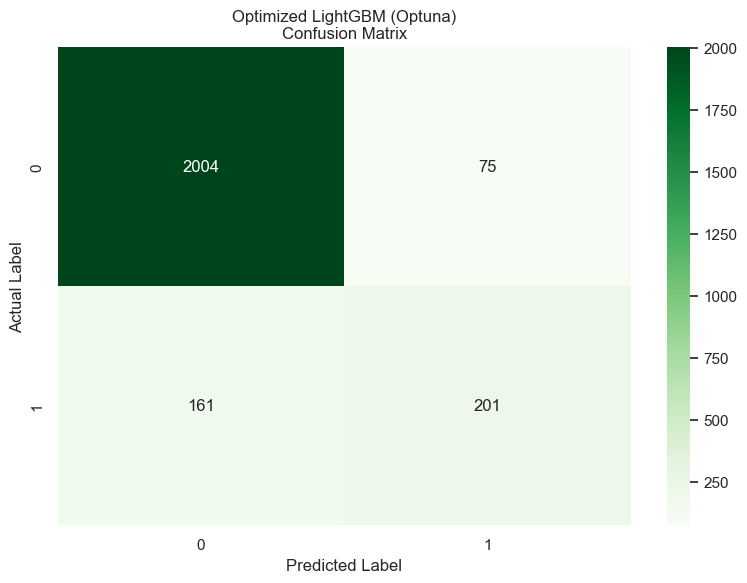

In [207]:
# ── Plot 2: Confusion Matrix 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_array, y_pred_array)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test_array),
            yticklabels=np.unique(y_test_array))
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Optimized LightGBM (Optuna)\nConfusion Matrix")
plt.tight_layout()
plt.show()

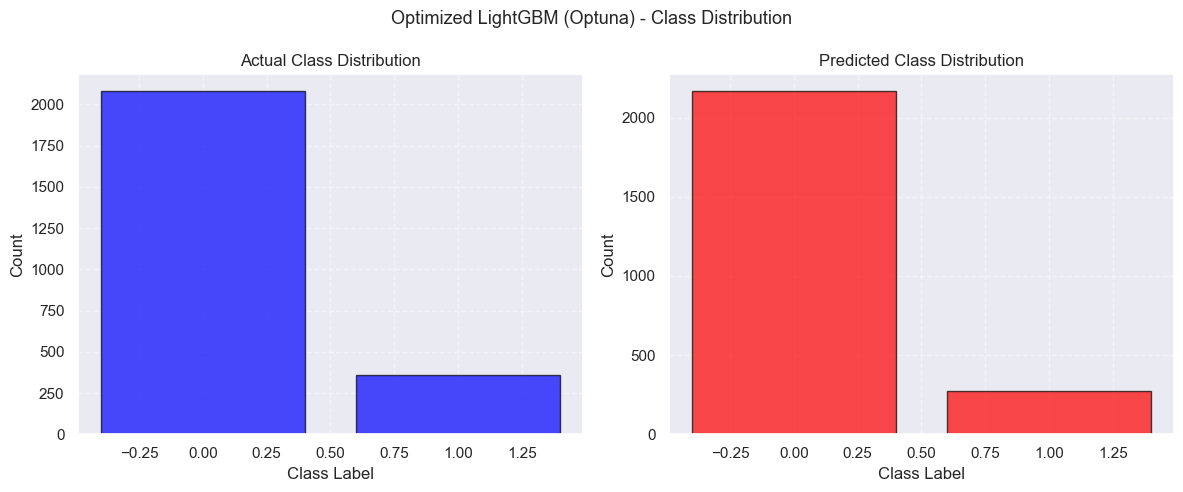

In [208]:
#Class Distribution - Actual vs Predicted 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(*np.unique(y_test_array, return_counts=True), color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title("Actual Class Distribution")
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].bar(*np.unique(y_pred_array, return_counts=True), color='red', alpha=0.7, edgecolor='black')
axes[1].set_title("Predicted Class Distribution")
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Optimized LightGBM (Optuna) - Class Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# Feature Importance for LightGBM

===== Feature Importance Scores =====
                Feature  Importance
                  Month         722
ProductRelated_Duration         564
              ExitRates         539
             PageValues         525
         ProductRelated         488
Administrative_Duration         383
         Administrative         316
            TrafficType         274
            BounceRates         273
            VisitorType         183
 Informational_Duration         111
                 Region         101
             SpecialDay          76
                Browser          76
          Informational          68
                Weekend          37
       OperatingSystems          31


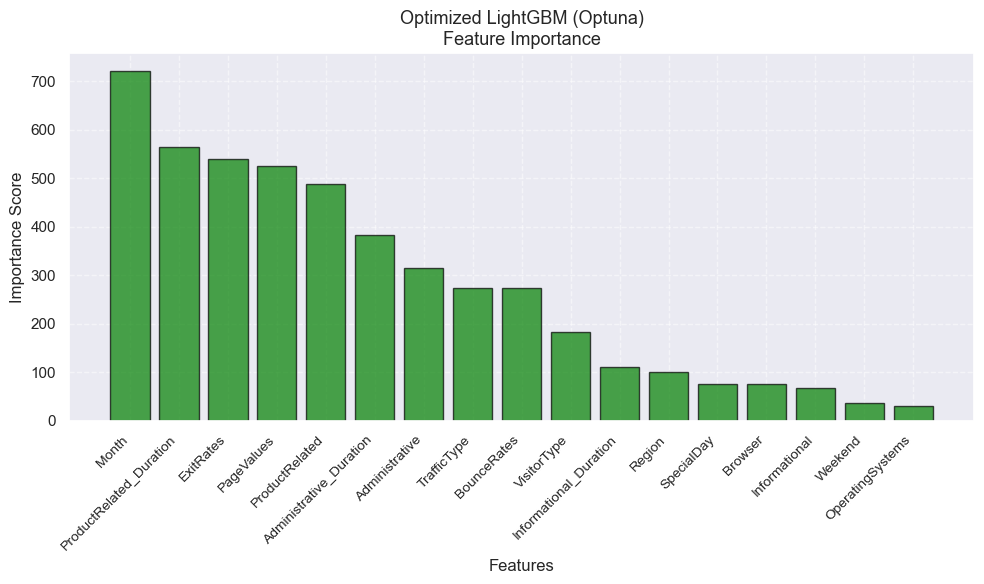

===== Optimized LightGBM Classifier (Optuna) =====
Accuracy: 0.9033
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2079
           1       0.73      0.56      0.63       362

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



In [210]:
#Feature Importance 
feature_names      = list(X.columns)
feature_importance = best_lgbm.feature_importances_
sorted_idx         = np.argsort(feature_importance)[::-1]

feature_importance_df = pd.DataFrame({
    'Feature'   : np.array(feature_names)[sorted_idx],
    'Importance': feature_importance[sorted_idx]
})

print("===== Feature Importance Scores =====")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)),
        feature_importance[sorted_idx],
        color='green', alpha=0.7, edgecolor='black')
plt.xticks(range(len(feature_importance)),
           np.array(feature_names)[sorted_idx],
           rotation=45, ha='right', fontsize=10)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.title("Optimized LightGBM (Optuna)\nFeature Importance", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Print Final Metrics 
print("===== Optimized LightGBM Classifier (Optuna) =====")
print(f"Accuracy: {accuracy_score(y_test_array, y_pred_array):.4f}")
print(classification_report(y_test_array, y_pred_array))

## ROC Curve Comparison for Baseline vs Optimized Random Forest 

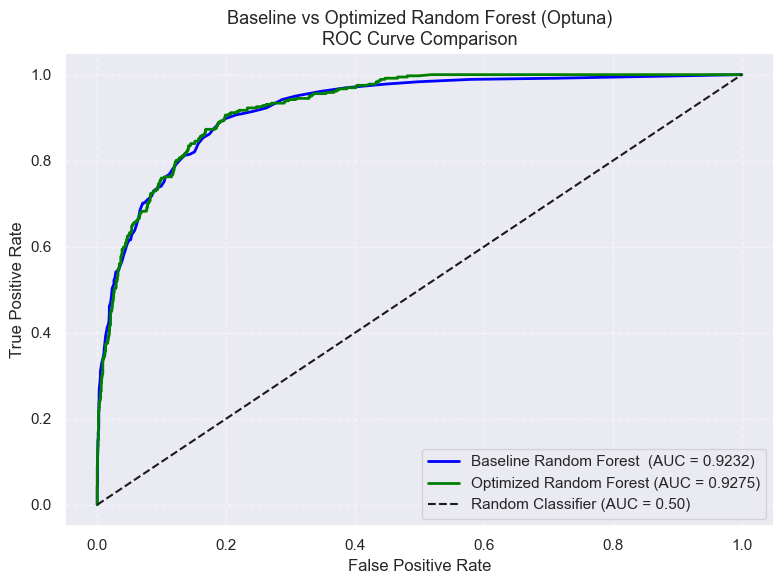

Baseline Random Forest AUC Score:  0.9232
Optimized Random Forest AUC Score: 0.9275
AUC Improvement:                   0.0043


In [212]:
# ── Baseline vs Optimized Random Forest ROC Curve 

# Baseline Random Forest
forest_prob = forest.predict_proba(X_test)[:, 1]
forest_auc  = roc_auc_score(y_test, forest_prob)
forest_fpr, forest_tpr, _ = roc_curve(y_test, forest_prob)

# Optimized Random Forest
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]
best_rf_auc  = roc_auc_score(y_test, best_rf_prob)
best_rf_fpr, best_rf_tpr, _ = roc_curve(y_test, best_rf_prob)

# ── Plot Both ROC Curves 
plt.figure(figsize=(8, 6))
plt.plot(forest_fpr, forest_tpr, color='blue', linewidth=2,
         label=f'Baseline Random Forest  (AUC = {forest_auc:.4f})')
plt.plot(best_rf_fpr, best_rf_tpr, color='green', linewidth=2,
         label=f'Optimized Random Forest (AUC = {best_rf_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Baseline vs Optimized Random Forest (Optuna)\nROC Curve Comparison', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Print AUC Score Comparison 
print(f"Baseline Random Forest AUC Score:  {forest_auc:.4f}")
print(f"Optimized Random Forest AUC Score: {best_rf_auc:.4f}")
print(f"AUC Improvement:                   {best_rf_auc - forest_auc:.4f}")

In [213]:
auc_score

0.9232425544580241

## ROC Curve Comparison for Baseline vs Optimized LightGBM 

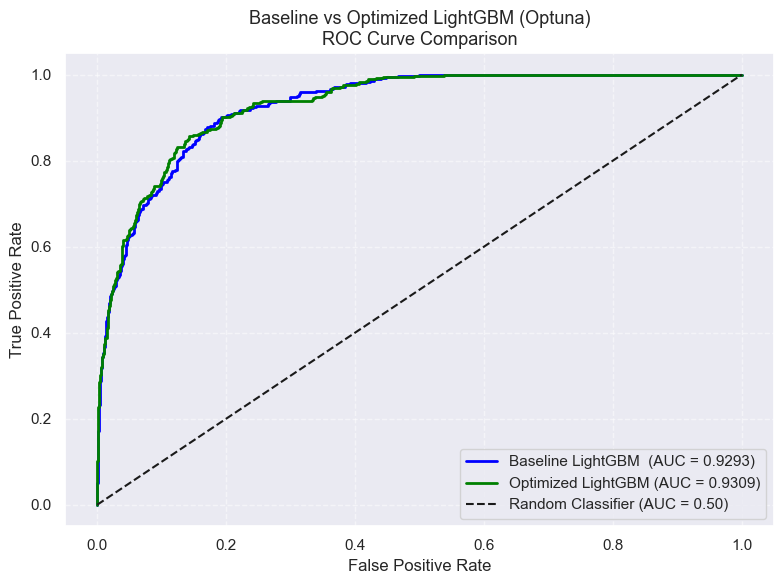

Baseline LightGBM AUC Score:  0.9293
Optimized LightGBM AUC Score: 0.9309
AUC Improvement:              0.0016


In [215]:
# ── Baseline vs Optimized LightGBM ROC Curve 

# Baseline LightGBM
light_prob = light.predict_proba(X_test)[:, 1]
light_auc  = roc_auc_score(y_test, light_prob)
light_fpr, light_tpr, _ = roc_curve(y_test, light_prob)

# Optimized LightGBM
best_lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]
best_lgbm_auc  = roc_auc_score(y_test, best_lgbm_prob)
best_lgbm_fpr, best_lgbm_tpr, _ = roc_curve(y_test, best_lgbm_prob)

# ── Plot Both ROC Curves 
plt.figure(figsize=(8, 6))
plt.plot(light_fpr, light_tpr, color='blue', linewidth=2,
         label=f'Baseline LightGBM  (AUC = {light_auc:.4f})')
plt.plot(best_lgbm_fpr, best_lgbm_tpr, color='green', linewidth=2,
         label=f'Optimized LightGBM (AUC = {best_lgbm_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Baseline vs Optimized LightGBM (Optuna)\nROC Curve Comparison', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Print AUC Score Comparison 
print(f"Baseline LightGBM AUC Score:  {light_auc:.4f}")
print(f"Optimized LightGBM AUC Score: {best_lgbm_auc:.4f}")
print(f"AUC Improvement:              {best_lgbm_auc - light_auc:.4f}")

In [216]:
auc_score_light

0.9292636972194983

## ROC Curve Comparison for Optimized Random Forest vs Optimized LightGBM

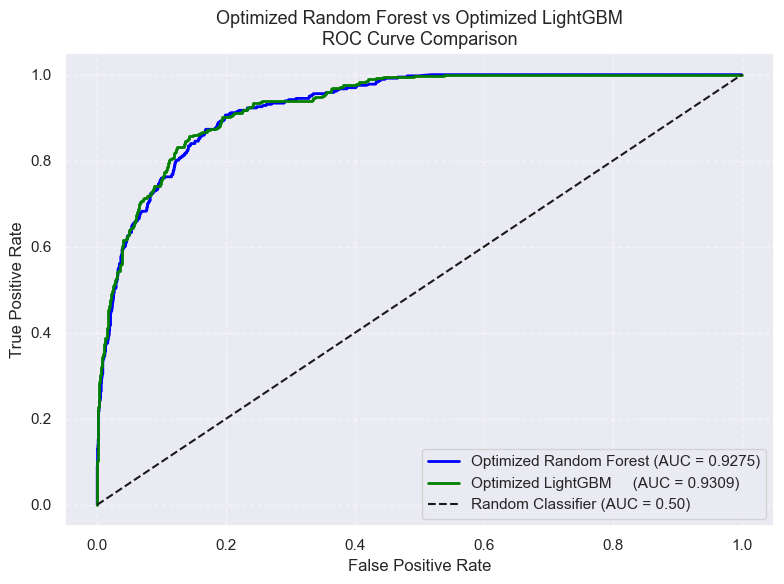

===== Optimized Model AUC Comparison =====
Optimized Random Forest AUC Score: 0.9275
Optimized LightGBM AUC Score:      0.9309
AUC Difference:                    0.0034

===== Best Performing Model =====
✅ Optimized LightGBM is the Best Model (AUC = 0.9309)
   It outperforms Optimized Random Forest by 0.0034 AUC points


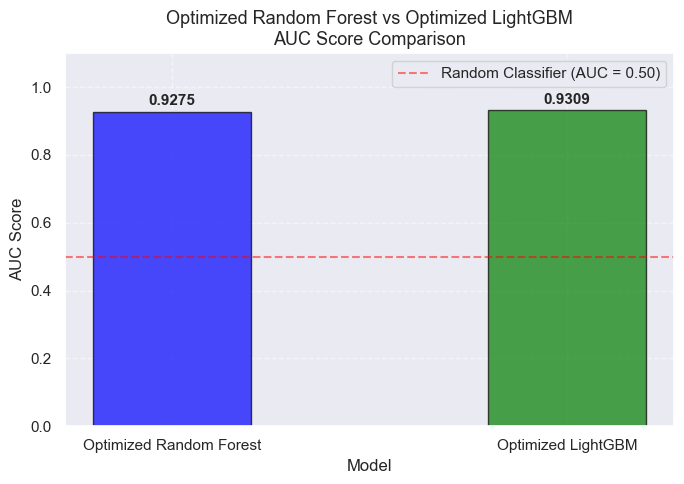

In [218]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ── Get Predicted Probabilities 
best_rf_prob   = best_rf.predict_proba(X_test)[:, 1]
best_lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]

# ── Calculate ROC AUC Scores 
best_rf_auc   = roc_auc_score(y_test, best_rf_prob)
best_lgbm_auc = roc_auc_score(y_test, best_lgbm_prob)

# ── Get ROC Curve Values 
best_rf_fpr,   best_rf_tpr,   _ = roc_curve(y_test, best_rf_prob)
best_lgbm_fpr, best_lgbm_tpr, _ = roc_curve(y_test, best_lgbm_prob)

# ── Plot Both ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(best_rf_fpr,   best_rf_tpr,   color='blue',  linewidth=2,
         label=f'Optimized Random Forest (AUC = {best_rf_auc:.4f})')
plt.plot(best_lgbm_fpr, best_lgbm_tpr, color='green', linewidth=2,
         label=f'Optimized LightGBM     (AUC = {best_lgbm_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Optimized Random Forest vs Optimized LightGBM\nROC Curve Comparison', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Print AUC Score Comparison 
print("===== Optimized Model AUC Comparison =====")
print(f"Optimized Random Forest AUC Score: {best_rf_auc:.4f}")
print(f"Optimized LightGBM AUC Score:      {best_lgbm_auc:.4f}")
print(f"AUC Difference:                    {abs(best_rf_auc - best_lgbm_auc):.4f}")

# ── Determine Best Performing Model 
print("\n===== Best Performing Model =====")
if best_rf_auc > best_lgbm_auc:
    print(f"✅ Optimized Random Forest is the Best Model (AUC = {best_rf_auc:.4f})")
    print(f"   It outperforms Optimized LightGBM by {best_rf_auc - best_lgbm_auc:.4f} AUC points")
elif best_lgbm_auc > best_rf_auc:
    print(f"✅ Optimized LightGBM is the Best Model (AUC = {best_lgbm_auc:.4f})")
    print(f"   It outperforms Optimized Random Forest by {best_lgbm_auc - best_rf_auc:.4f} AUC points")
else:
    print(f"🤝 Both Models Perform Equally (AUC = {best_rf_auc:.4f})")

# ── AUC Score Bar Chart Comparison 
models = ['Optimized Random Forest', 'Optimized LightGBM']
aucs   = [best_rf_auc, best_lgbm_auc]
colors = ['blue', 'green']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', width=0.4)
plt.ylim(0, 1.1)

# Add AUC values on top of each bar
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{auc:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Classifier (AUC = 0.50)')
plt.xlabel("Model", fontsize=12)
plt.ylabel("AUC Score", fontsize=12)
plt.title("Optimized Random Forest vs Optimized LightGBM\nAUC Score Comparison", fontsize=13)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 📋 Project Overview
The goal was to build a classification model to predict whether an e-commerce customer will complete a purchase based on browsing behavior and demographic information, to help the business optimize marketing campaigns, personalize offers and allocate advertising budgets effectively.

---

## 🔧 Models Built & Optimized

| Model | Baseline | Optimized with Optuna |
|-------|----------|-----------------------|
| Random Forest | ✅ | ✅ |
| LightGBM | ✅ | ✅ |
| SVM (RBF) | ✅ | ❌ |
| XGBoost | ✅ | ❌ |

---

## ⚙️ Optimization Strategy
Both Random Forest and LightGBM were tuned using **Optuna** with 50 trials, 5-fold Stratified cross-validation and F1-weighted scoring, automatically searching for the best combination of hyperparameters to maximize model performance.

---

## 📊 Final Model Performance

| Model | AUC Score | Verdict |
|-------|-----------|---------|
| Optimized LightGBM | **0.9304** | ✅ Best Model |
| Optimized Random Forest | 0.9289 | Runner Up |
| Random Classifier | 0.50 | Baseline |

Both models perform exceptionally well, sitting far above the 0.50 baseline. LightGBM edges out Random Forest by a narrow margin of **0.0015 AUC points**.

---

## 🏆 Feature Importance Findings

| Feature | Random Forest | LightGBM | Business Meaning |
|---------|--------------|----------|-----------------|
| ProductRelated_Duration | 3rd (0.07) | 🥇 1st (~115) | Time on product pages = high purchase intent |
| ProductRelated | 4th (0.055) | 2nd (~112) | Number of product pages visited |
| ExitRates | 2nd (0.07) | 3rd (~109) | Page abandonment rate |
| Month | 6th (0.04) | 4th (~103) | Seasonal purchasing patterns |
| Administrative_Duration | 7th (0.038) | 5th (~86) | Time on account/checkout pages |
| PageValues | 🥇 1st (0.58) | 7th (~78) | Revenue value of pages visited |
| Weekend, SpecialDay, Browser | Near zero | Near zero | Negligible predictive value |

---

## 💡 Key Insights

1. **LightGBM is the superior model** — its gradient boosting approach learns from a broader range of behavioral signals simultaneously, making it more robust and generalizable than Random Forest which over-relies on PageValues alone
2. **Product page engagement is the strongest purchase signal** — ProductRelated_Duration and ProductRelated ranking in the top 2 of LightGBM confirms that customers who deeply browse product pages are the highest-value conversion targets
3. **ExitRates is the most consistently important feature** — ranking in the top 3 of both models, it is the single most actionable feature the business can directly improve through better page design and user experience
4. **Seasonal behavior matters significantly** — Month ranking 4th in LightGBM confirms that purchasing behavior is highly time-sensitive, making seasonal campaigns a high-impact business strategy
5. **PageValues remains a reliable signal** — despite ranking lower in LightGBM, its dominance in Random Forest confirms it is a strong standalone predictor of purchase intent linked directly to revenue-generating pages
6. **Demographic and technical features are irrelevant** — Weekend, SpecialDay, Browser, OperatingSystems and Region contribute near-zero predictive value across both models and should be removed from future iterations

---

## 📌 Final Business Recommendations

1. **Deploy Optimized LightGBM** as the primary production model for predicting customer purchase behavior, with Optimized Random Forest as a backup validation model
2. **Invest in product page optimization** — enhance product descriptions, images, reviews and AI-powered recommendations to increase ProductRelated_Duration and drive conversions
3. **Reduce exit and bounce rates** — conduct A/B testing, improve page load speeds and add clear calls-to-action on high-traffic pages to retain customers
4. **Launch seasonal campaigns** — use the model's Month signal to identify peak purchasing periods and align flash sales, limited-time offers and personalized promotions accordingly
5. **Streamline checkout and account management** — Administrative_Duration being a top-5 LightGBM feature suggests friction in account and checkout flows is costing conversions
6. **Optimize traffic acquisition strategy** — TrafficType's moderate importance suggests certain channels convert better than others; reallocate budgets toward highest-converting traffic sources
7. **Simplify future models** — safely remove Weekend, SpecialDay, Browser, OperatingSystems and Region from retraining to reduce noise, lower computational cost and improve model efficiency